<a href="https://colab.research.google.com/github/Janajeevi/CN7030-ASSIGNMENT-2-/blob/main/WEEK_9_Bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

In [2]:
spark = SparkSession.builder \
.master("local[*]") \
.appName("Bitcoin Forecasting using PySpark") \
.getOrCreate()
print("Spark Version:", spark.version)

Spark Version: 4.0.3


In [3]:
spark_df = spark.read.csv(
"/content/btcusd_1-min_data.csv",
header=True,
inferSchema=True
)
spark_df.show(5)

+----------+----+----+----+-----+------+
| Timestamp|Open|High| Low|Close|Volume|
+----------+----+----+----+-----+------+
|1325376060|4.58|4.58|4.58| 4.58|   0.0|
|1325376120|4.58|4.58|4.58| 4.58|   0.0|
|1325376180|4.58|4.58|4.58| 4.58|   0.0|
|1325376240|4.58|4.58|4.58| 4.58|   0.0|
|1325376300|4.58|4.58|4.58| 4.58|   0.0|
+----------+----+----+----+-----+------+
only showing top 5 rows


In [6]:
spark_df.printSchema()
print("Number of Rows :", spark_df.count())
print("Number of Columns :", len(spark_df.columns))

root
 |-- Timestamp: integer (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)

Number of Rows : 1236604
Number of Columns : 6


In [7]:
from pyspark.sql.functions import col,isnan,when,count
spark_df.select(
[count(when(isnan(c) | col(c).isNull(), c)).alias(c)
for c in spark_df.columns]
).show()

+---------+----+----+---+-----+------+
|Timestamp|Open|High|Low|Close|Volume|
+---------+----+----+---+-----+------+
|        0|   0|   0|  0|    0|     0|
+---------+----+----+---+-----+------+



In [8]:
spark_df = spark_df.dropna()
print("Rows after removing missing values:")
print(spark_df.count())

Rows after removing missing values:
1236604


In [9]:
spark_df = spark_df.withColumn(
"Date",
from_unixtime(col("Timestamp")).cast("timestamp")
)
spark_df.select("Timestamp","Date").show(5,False)

+----------+-------------------+
|Timestamp |Date               |
+----------+-------------------+
|1325376060|2012-01-01 00:01:00|
|1325376120|2012-01-01 00:02:00|
|1325376180|2012-01-01 00:03:00|
|1325376240|2012-01-01 00:04:00|
|1325376300|2012-01-01 00:05:00|
+----------+-------------------+
only showing top 5 rows


In [10]:
spark_df = spark_df.orderBy("Date")

In [11]:
spark_df.select("Date","Close").show(10,False)

+-------------------+-----+
|Date               |Close|
+-------------------+-----+
|2012-01-01 00:01:00|4.58 |
|2012-01-01 00:02:00|4.58 |
|2012-01-01 00:03:00|4.58 |
|2012-01-01 00:04:00|4.58 |
|2012-01-01 00:05:00|4.58 |
|2012-01-01 00:06:00|4.58 |
|2012-01-01 00:07:00|4.58 |
|2012-01-01 00:08:00|4.58 |
|2012-01-01 00:09:00|4.58 |
|2012-01-01 00:10:00|4.58 |
+-------------------+-----+
only showing top 10 rows


In [12]:
spark_df.describe().show()

+-------+-------------------+------------------+------------------+------------------+-----------------+-----------------+
|summary|          Timestamp|              Open|              High|               Low|            Close|           Volume|
+-------+-------------------+------------------+------------------+------------------+-----------------+-----------------+
|  count|            1236604|           1236604|           1236604|           1236604|          1236604|          1236604|
|   mean|       1.36247415E9| 176.0158288991468|176.19415924580485|175.82387017994745|176.0135917884806|6.423490603390506|
| stddev|2.141861822868132E7|264.51941488565967|264.83258371283875| 264.1861688134976|264.5207150795318|32.84538253149714|
|    min|         1325376060|               3.8|               3.8|               3.8|              3.8|              0.0|
|    max|         1399572240|            1163.0|            1163.0|           1162.99|           1163.0|    4111.87610626|
+-------+-------

In [13]:
sample_df = spark_df.limit(5000).toPandas()
sample_df.head()

,Timestamp,Open,High,Low,Close,Volume,Date
0,1325376060,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:01:00
1,1325376120,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:02:00
2,1325376180,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:03:00
3,1325376240,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:04:00
4,1325376300,4.58,4.58,4.58,4.58,0.0,2012-01-01 00:05:00


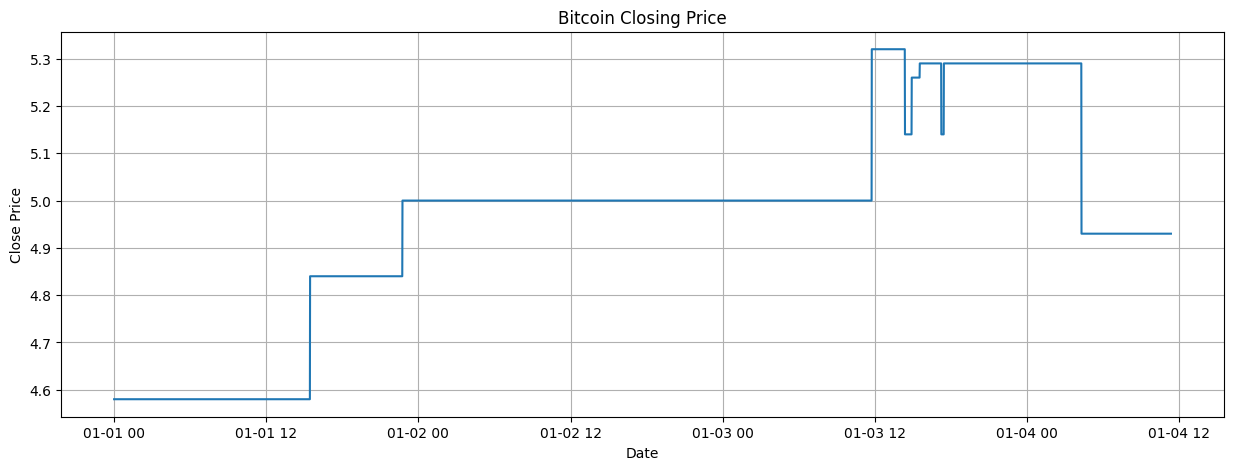

In [14]:
plt.figure(figsize=(15,5))
plt.plot(sample_df["Date"],
sample_df["Close"])
plt.title("Bitcoin Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

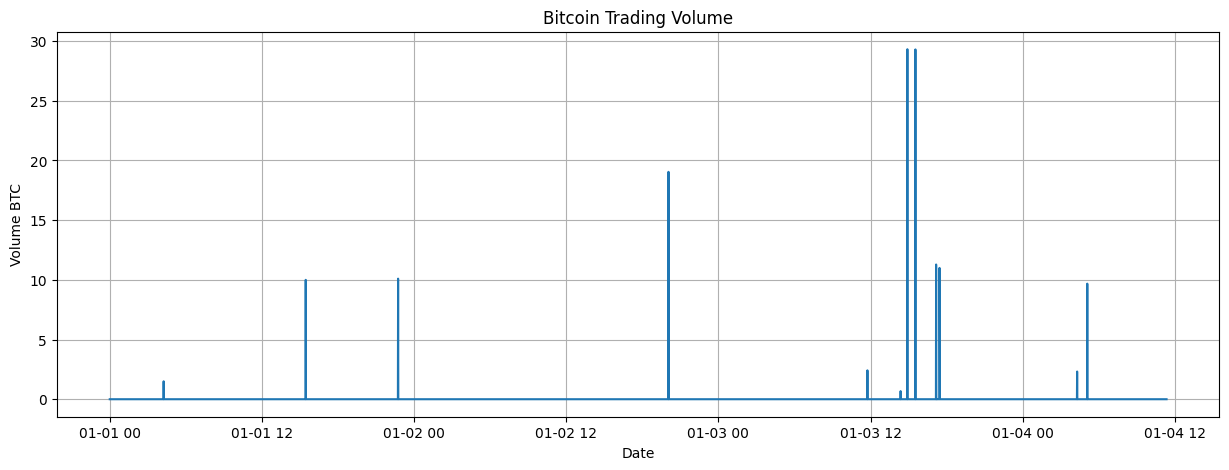

In [15]:
plt.figure(figsize=(15,5))
plt.plot(sample_df["Date"],
sample_df["Volume"])
plt.title("Bitcoin Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume BTC")
plt.grid(True)
plt.show()

In [16]:
pdf = sample_df[[
"Open",
"High",
"Low",
"Close",
"Volume" # Corrected from 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price'
]]
corr = pdf.corr()
corr

,Open,High,Low,Close,Volume
Open,1.000000,1.000000,1.000000,1.000000,0.033443
High,1.000000,1.000000,1.000000,1.000000,0.033443
Low,1.000000,1.000000,1.000000,1.000000,0.033443
Close,1.000000,1.000000,1.000000,1.000000,0.033443
Volume,0.033443,0.033443,0.033443,0.033443,1.000000


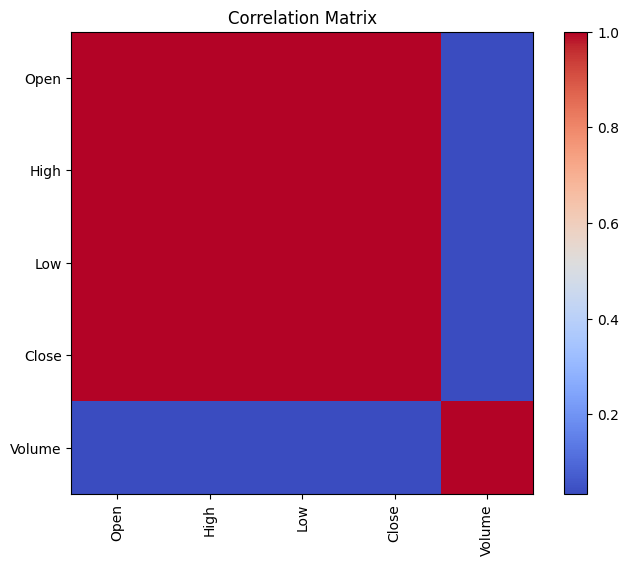

In [17]:
pdf = sample_df[[
"Open",
"High",
"Low",
"Close",
"Volume"
]]
corr = pdf.corr()
plt.figure(figsize=(8,6))
plt.imshow(corr,
cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)),
corr.columns,
rotation=90)
plt.yticks(range(len(corr.columns)),
corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [18]:
from pyspark.sql.window import Window
from pyspark.sql.functions import *
windowSpec = Window.orderBy("Date")

In [19]:
spark_df = spark_df \
.withColumn("Lag_1", lag("Close", 1).over(windowSpec)) \
.withColumn("Lag_2", lag("Close", 2).over(windowSpec)) \
.withColumn("Lag_3", lag("Close", 3).over(windowSpec))
spark_df.select(
"Date",
"Close",
"Lag_1",
"Lag_2",
"Lag_3"
).show(10, False)

+-------------------+-----+-----+-----+-----+
|Date               |Close|Lag_1|Lag_2|Lag_3|
+-------------------+-----+-----+-----+-----+
|2012-01-01 00:01:00|4.58 |NULL |NULL |NULL |
|2012-01-01 00:02:00|4.58 |4.58 |NULL |NULL |
|2012-01-01 00:03:00|4.58 |4.58 |4.58 |NULL |
|2012-01-01 00:04:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:05:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:06:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:07:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:08:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:09:00|4.58 |4.58 |4.58 |4.58 |
|2012-01-01 00:10:00|4.58 |4.58 |4.58 |4.58 |
+-------------------+-----+-----+-----+-----+
only showing top 10 rows


In [20]:
rollingWindow = Window.orderBy("Date").rowsBetween(-4,0)

In [21]:
spark_df = spark_df.withColumn(
"Rolling_Mean",
avg("Close").over(rollingWindow)
)
spark_df.select(
"Date",
"Close",
"Rolling_Mean"
).show(10, False)

+-------------------+-----+------------+
|Date               |Close|Rolling_Mean|
+-------------------+-----+------------+
|2012-01-01 00:01:00|4.58 |4.58        |
|2012-01-01 00:02:00|4.58 |4.58        |
|2012-01-01 00:03:00|4.58 |4.58        |
|2012-01-01 00:04:00|4.58 |4.58        |
|2012-01-01 00:05:00|4.58 |4.58        |
|2012-01-01 00:06:00|4.58 |4.58        |
|2012-01-01 00:07:00|4.58 |4.58        |
|2012-01-01 00:08:00|4.58 |4.58        |
|2012-01-01 00:09:00|4.58 |4.58        |
|2012-01-01 00:10:00|4.58 |4.58        |
+-------------------+-----+------------+
only showing top 10 rows


In [22]:
spark_df = spark_df.withColumn(
"Rolling_STD",
stddev("Close").over(rollingWindow)
)
spark_df.select(
"Date",
"Close",
"Rolling_STD"
).show(10, False)

+-------------------+-----+-----------+
|Date               |Close|Rolling_STD|
+-------------------+-----+-----------+
|2012-01-01 00:01:00|4.58 |NULL       |
|2012-01-01 00:02:00|4.58 |0.0        |
|2012-01-01 00:03:00|4.58 |0.0        |
|2012-01-01 00:04:00|4.58 |0.0        |
|2012-01-01 00:05:00|4.58 |0.0        |
|2012-01-01 00:06:00|4.58 |0.0        |
|2012-01-01 00:07:00|4.58 |0.0        |
|2012-01-01 00:08:00|4.58 |0.0        |
|2012-01-01 00:09:00|4.58 |0.0        |
|2012-01-01 00:10:00|4.58 |0.0        |
+-------------------+-----+-----------+
only showing top 10 rows


In [23]:
spark_df = spark_df.withColumn(
"Rolling_Max",
max("Close").over(rollingWindow)
)
spark_df.select(
"Date",
"Close",
"Rolling_Max"
).show(10, False)

+-------------------+-----+-----------+
|Date               |Close|Rolling_Max|
+-------------------+-----+-----------+
|2012-01-01 00:01:00|4.58 |4.58       |
|2012-01-01 00:02:00|4.58 |4.58       |
|2012-01-01 00:03:00|4.58 |4.58       |
|2012-01-01 00:04:00|4.58 |4.58       |
|2012-01-01 00:05:00|4.58 |4.58       |
|2012-01-01 00:06:00|4.58 |4.58       |
|2012-01-01 00:07:00|4.58 |4.58       |
|2012-01-01 00:08:00|4.58 |4.58       |
|2012-01-01 00:09:00|4.58 |4.58       |
|2012-01-01 00:10:00|4.58 |4.58       |
+-------------------+-----+-----------+
only showing top 10 rows


In [24]:
spark_df = spark_df.withColumn(
"Rolling_Min",
min("Close").over(rollingWindow)
)
spark_df.select(
"Date",
"Close",

"Rolling_Min"
).show(10, False)

+-------------------+-----+-----------+
|Date               |Close|Rolling_Min|
+-------------------+-----+-----------+
|2012-01-01 00:01:00|4.58 |4.58       |
|2012-01-01 00:02:00|4.58 |4.58       |
|2012-01-01 00:03:00|4.58 |4.58       |
|2012-01-01 00:04:00|4.58 |4.58       |
|2012-01-01 00:05:00|4.58 |4.58       |
|2012-01-01 00:06:00|4.58 |4.58       |
|2012-01-01 00:07:00|4.58 |4.58       |
|2012-01-01 00:08:00|4.58 |4.58       |
|2012-01-01 00:09:00|4.58 |4.58       |
|2012-01-01 00:10:00|4.58 |4.58       |
+-------------------+-----+-----------+
only showing top 10 rows


In [25]:
spark_df = spark_df.withColumn(
"Rolling_Range",
col("Rolling_Max") - col("Rolling_Min")
)
spark_df.select(
"Date",
"Rolling_Range"
).show(10, False)

+-------------------+-------------+
|Date               |Rolling_Range|
+-------------------+-------------+
|2012-01-01 00:01:00|0.0          |
|2012-01-01 00:02:00|0.0          |
|2012-01-01 00:03:00|0.0          |
|2012-01-01 00:04:00|0.0          |
|2012-01-01 00:05:00|0.0          |
|2012-01-01 00:06:00|0.0          |
|2012-01-01 00:07:00|0.0          |
|2012-01-01 00:08:00|0.0          |
|2012-01-01 00:09:00|0.0          |
|2012-01-01 00:10:00|0.0          |
+-------------------+-------------+
only showing top 10 rows


In [26]:
spark_df = spark_df.withColumn(
"Price_Change",
col("Close") - col("Lag_1")
)
spark_df.select(
"Date",
"Price_Change"
).show(10, False)

+-------------------+------------+
|Date               |Price_Change|
+-------------------+------------+
|2012-01-01 00:01:00|NULL        |
|2012-01-01 00:02:00|0.0         |
|2012-01-01 00:03:00|0.0         |
|2012-01-01 00:04:00|0.0         |
|2012-01-01 00:05:00|0.0         |
|2012-01-01 00:06:00|0.0         |
|2012-01-01 00:07:00|0.0         |
|2012-01-01 00:08:00|0.0         |
|2012-01-01 00:09:00|0.0         |
|2012-01-01 00:10:00|0.0         |
+-------------------+------------+
only showing top 10 rows


In [27]:
spark_df = spark_df.withColumn(
"Return",
((col("Close") - col("Lag_1")) / col("Lag_1")) * 100
)
spark_df.select(
"Date",

"Return"
).show(10, False)

+-------------------+------+
|Date               |Return|
+-------------------+------+
|2012-01-01 00:01:00|NULL  |
|2012-01-01 00:02:00|0.0   |
|2012-01-01 00:03:00|0.0   |
|2012-01-01 00:04:00|0.0   |
|2012-01-01 00:05:00|0.0   |
|2012-01-01 00:06:00|0.0   |
|2012-01-01 00:07:00|0.0   |
|2012-01-01 00:08:00|0.0   |
|2012-01-01 00:09:00|0.0   |
|2012-01-01 00:10:00|0.0   |
+-------------------+------+
only showing top 10 rows


In [28]:
spark_df = spark_df.withColumn(
"Target",
lead("Close",1).over(windowSpec)
)
spark_df.select(
"Date",
"Close",
"Target"
).show(10, False)

+-------------------+-----+------+
|Date               |Close|Target|
+-------------------+-----+------+
|2012-01-01 00:01:00|4.58 |4.58  |
|2012-01-01 00:02:00|4.58 |4.58  |
|2012-01-01 00:03:00|4.58 |4.58  |
|2012-01-01 00:04:00|4.58 |4.58  |
|2012-01-01 00:05:00|4.58 |4.58  |
|2012-01-01 00:06:00|4.58 |4.58  |
|2012-01-01 00:07:00|4.58 |4.58  |
|2012-01-01 00:08:00|4.58 |4.58  |
|2012-01-01 00:09:00|4.58 |4.58  |
|2012-01-01 00:10:00|4.58 |4.58  |
+-------------------+-----+------+
only showing top 10 rows


In [29]:
spark_df = spark_df.dropna()
print("Remaining Rows:", spark_df.count())

Remaining Rows: 1236600


In [30]:
spark_df.select(
"Date",
"Close",
"Lag_1",
"Lag_2",
"Lag_3",
"Rolling_Mean",
"Rolling_STD",
"Rolling_Max",
"Rolling_Min",
"Rolling_Range",
"Price_Change",
"Return",
"Target"
).show(15, False)

+-------------------+-----+-----+-----+-----+------------+-----------+-----------+-----------+-------------+------------+------+------+
|Date               |Close|Lag_1|Lag_2|Lag_3|Rolling_Mean|Rolling_STD|Rolling_Max|Rolling_Min|Rolling_Range|Price_Change|Return|Target|
+-------------------+-----+-----+-----+-----+------------+-----------+-----------+-----------+-------------+------------+------+------+
|2012-01-01 00:04:00|4.58 |4.58 |4.58 |4.58 |4.58        |0.0        |4.58       |4.58       |0.0          |0.0         |0.0   |4.58  |
|2012-01-01 00:05:00|4.58 |4.58 |4.58 |4.58 |4.58        |0.0        |4.58       |4.58       |0.0          |0.0         |0.0   |4.58  |
|2012-01-01 00:06:00|4.58 |4.58 |4.58 |4.58 |4.58        |0.0        |4.58       |4.58       |0.0          |0.0         |0.0   |4.58  |
|2012-01-01 00:07:00|4.58 |4.58 |4.58 |4.58 |4.58        |0.0        |4.58       |4.58       |0.0          |0.0         |0.0   |4.58  |
|2012-01-01 00:08:00|4.58 |4.58 |4.58 |4.58 |4.5

In [31]:
spark_df.printSchema()

root
 |-- Timestamp: integer (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)
 |-- Date: timestamp (nullable = true)
 |-- Lag_1: double (nullable = true)
 |-- Lag_2: double (nullable = true)
 |-- Lag_3: double (nullable = true)
 |-- Rolling_Mean: double (nullable = true)
 |-- Rolling_STD: double (nullable = true)
 |-- Rolling_Max: double (nullable = true)
 |-- Rolling_Min: double (nullable = true)
 |-- Rolling_Range: double (nullable = true)
 |-- Price_Change: double (nullable = true)
 |-- Return: double (nullable = true)
 |-- Target: double (nullable = true)



In [32]:
feature_columns = [
"Open",
"High",
"Low",
"Volume_(BTC)",
"Volume_(Currency)",
"Weighted_Price",
"Lag_1",
"Lag_2",
"Lag_3",
"Rolling_Mean",
"Rolling_STD",
"Rolling_Max",
"Rolling_Min",
"Rolling_Range",
"Price_Change",
"Return"
]
label_column = "Target"
print("Number of Features:", len(feature_columns))
print(feature_columns)

Number of Features: 16
['Open', 'High', 'Low', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean', 'Rolling_STD', 'Rolling_Max', 'Rolling_Min', 'Rolling_Range', 'Price_Change', 'Return']


In [33]:
from pyspark.ml.feature import VectorAssembler
# Redefine feature_columns to use the correct column names
feature_columns = [
"Open",
"High",
"Low",
"Volume", # Corrected from 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price'
"Lag_1",
"Lag_2",
"Lag_3",
"Rolling_Mean",
"Rolling_STD",
"Rolling_Max",
"Rolling_Min",
"Rolling_Range",
"Price_Change",

"Return"
]
assembler = VectorAssembler(
inputCols=feature_columns,
outputCol="features"
)
assembled_df = assembler.transform(spark_df)
assembled_df.select("features", "Target").show(5, truncate=False)

+------------------------------------------------------------------+------+
|features                                                          |Target|
+------------------------------------------------------------------+------+
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
|[4.58,4.58,4.58,0.0,4.58,4.58,4.58,4.58,0.0,4.58,4.58,0.0,0.0,0.0]|4.58  |
+------------------------------------------------------------------+------+
only showing top 5 rows


In [34]:
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(
inputCol="features",
outputCol="scaledFeatures",
withMean=True,
withStd=True
)
scalerModel = scaler.fit(assembled_df)
scaled_df = scalerModel.transform(assembled_df)
scaled_df.select(
"scaledFeatures",
"Target"
).show(5, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|scaledFeatures                                                                                                                                                                                                                                                                                 |Target|
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|[-0.6481033158018958,-0.6480102938600982,-0.6481942326770775,-0.19556786424060113,-0.6480904899409456,-0.648

In [35]:
final_df = scaled_df.select(
"Date",
"scaledFeatures",
col("Target").alias("label")
)
final_df.show(5)

+-------------------+--------------------+-----+
|               Date|      scaledFeatures|label|
+-------------------+--------------------+-----+
|2012-01-01 00:04:00|[-0.6481033158018...| 4.58|
|2012-01-01 00:05:00|[-0.6481033158018...| 4.58|
|2012-01-01 00:06:00|[-0.6481033158018...| 4.58|
|2012-01-01 00:07:00|[-0.6481033158018...| 4.58|
|2012-01-01 00:08:00|[-0.6481033158018...| 4.58|
+-------------------+--------------------+-----+
only showing top 5 rows


In [36]:
print("Total Rows:", final_df.count())

Total Rows: 1236600


In [38]:
total_rows = final_df.count()
train_rows = int(total_rows * 0.80)
print("Training Rows:", train_rows)
print("Testing Rows :", total_rows - train_rows)

from pyspark.sql.window import Window
from pyspark.sql.functions import row_number
indexWindow = Window.orderBy("Date")
indexed_df = final_df.withColumn(
    "row_num",
    row_number().over(indexWindow)
)
indexed_df.show(5)

Training Rows: 989280
Testing Rows : 247320
+-------------------+--------------------+-----+-------+
|               Date|      scaledFeatures|label|row_num|
+-------------------+--------------------+-----+-------+
|2012-01-01 00:04:00|[-0.6481033158018...| 4.58|      1|
|2012-01-01 00:05:00|[-0.6481033158018...| 4.58|      2|
|2012-01-01 00:06:00|[-0.6481033158018...| 4.58|      3|
|2012-01-01 00:07:00|[-0.6481033158018...| 4.58|      4|
|2012-01-01 00:08:00|[-0.6481033158018...| 4.58|      5|
+-------------------+--------------------+-----+-------+
only showing top 5 rows


In [39]:
train_df = indexed_df.filter(
col("row_num") <= train_rows
).drop("row_num")
test_df = indexed_df.filter(
col("row_num") > train_rows
).drop("row_num")
print("Training Dataset Size:", train_df.count())
print("Testing Dataset Size:", test_df.count())

Training Dataset Size: 989280
Testing Dataset Size: 247320


In [40]:
from pyspark.ml.regression import LinearRegression
lr = LinearRegression(
featuresCol="scaledFeatures",
labelCol="label",
predictionCol="prediction",
maxIter=100
)
lr_model = lr.fit(train_df)
print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [41]:
lr_predictions = lr_model.transform(test_df)
lr_predictions.select(
"Date",
"label",
"prediction"
).show(10, False)

+-------------------+------+------------------+
|Date               |label |prediction        |
+-------------------+------+------------------+
|2013-11-18 00:04:00|476.04|477.8435604015309 |
|2013-11-18 00:05:00|475.9 |476.83474005503103|
|2013-11-18 00:06:00|475.99|475.8243590107047 |
|2013-11-18 00:07:00|475.99|475.9923668565142 |
|2013-11-18 00:08:00|478.77|476.13275594158506|
|2013-11-18 00:09:00|476.39|478.25001586333246|
|2013-11-18 00:10:00|476.38|476.48561818142196|
|2013-11-18 00:11:00|475.89|476.5117497390488 |
|2013-11-18 00:12:00|475.28|475.88938982501793|
|2013-11-18 00:13:00|475.89|475.5466663045406 |
+-------------------+------+------------------+
only showing top 10 rows


In [42]:
from pyspark.ml.regression import GBTRegressor
gbt = GBTRegressor(
featuresCol="scaledFeatures",
labelCol="label",
predictionCol="prediction",

maxIter=100,
maxDepth=5,
seed=42
)
gbt_model = gbt.fit(train_df)
print("GBT Model Trained Successfully")

GBT Model Trained Successfully


In [43]:
gbt_predictions = gbt_model.transform(test_df)
gbt_predictions.select(
"Date",
"label",
"prediction"
).show(10, False)

+-------------------+------+------------------+
|Date               |label |prediction        |
+-------------------+------+------------------+
|2013-11-18 00:04:00|476.04|446.46770377867824|
|2013-11-18 00:05:00|475.9 |324.924939613256  |
|2013-11-18 00:06:00|475.99|332.6373031815802 |
|2013-11-18 00:07:00|475.99|349.5113795333146 |
|2013-11-18 00:08:00|478.77|333.2711889718212 |
|2013-11-18 00:09:00|476.39|323.33748508619465|
|2013-11-18 00:10:00|476.38|326.7818300101541 |
|2013-11-18 00:11:00|475.89|342.45238746145014|
|2013-11-18 00:12:00|475.28|353.74729246383623|
|2013-11-18 00:13:00|475.89|360.2335128079491 |
+-------------------+------+------------------+
only showing top 10 rows


In [44]:
print("Linear Regression Predictions")
lr_predictions.select(
"Date",
"label",
"prediction"
).show(5, False)
print("Gradient Boosted Trees Predictions")
gbt_predictions.select(
"Date",
"label",
"prediction"
).show(5, False)

Linear Regression Predictions
+-------------------+------+------------------+
|Date               |label |prediction        |
+-------------------+------+------------------+
|2013-11-18 00:04:00|476.04|477.8435604015309 |
|2013-11-18 00:05:00|475.9 |476.83474005503103|
|2013-11-18 00:06:00|475.99|475.8243590107047 |
|2013-11-18 00:07:00|475.99|475.9923668565142 |
|2013-11-18 00:08:00|478.77|476.13275594158506|
+-------------------+------+------------------+
only showing top 5 rows
Gradient Boosted Trees Predictions
+-------------------+------+------------------+
|Date               |label |prediction        |
+-------------------+------+------------------+
|2013-11-18 00:04:00|476.04|446.46770377867824|
|2013-11-18 00:05:00|475.9 |324.924939613256  |
|2013-11-18 00:06:00|475.99|332.6373031815802 |
|2013-11-18 00:07:00|475.99|349.5113795333146 |
|2013-11-18 00:08:00|478.77|333.2711889718212 |
+-------------------+------+------------------+
only showing top 5 rows


In [45]:
from pyspark.ml.evaluation import RegressionEvaluator
rmse_evaluator = RegressionEvaluator(
labelCol="label",
predictionCol="prediction",
metricName="rmse"
)

In [47]:
mae_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")

lr_rmse = rmse_evaluator.evaluate(lr_predictions)
lr_mae = mae_evaluator.evaluate(lr_predictions)

print("Linear Regression Performance")
print("-----------------------------")
print("RMSE :", lr_rmse)
print("MAE  :", lr_mae)

Linear Regression Performance
-----------------------------
RMSE : 2.2642140572635845
MAE  : 1.2112453955453366


In [48]:
gbt_rmse = rmse_evaluator.evaluate(gbt_predictions)
gbt_mae = mae_evaluator.evaluate(gbt_predictions)

print("Gradient Boosted Trees Performance")
print("----------------------------------")
print("RMSE :", gbt_rmse)
print("MAE  :", gbt_mae)

Gradient Boosted Trees Performance
----------------------------------
RMSE : 376.08362355934935
MAE  : 336.55475629801185


In [49]:
comparison = pd.DataFrame({
"Model": [
"Linear Regression",
"Gradient Boosted Trees"
],
"RMSE": [
lr_rmse,
gbt_rmse
],
"MAE": [
lr_mae,
gbt_mae
]
})
comparison

best_model = comparison.loc[
comparison["RMSE"].idxmin()
]
print(best_model)

Model    Linear Regression
RMSE              2.264214
MAE               1.211245
Name: 0, dtype: object


In [50]:
lr_pd = lr_predictions.select(
"Date",
"label",
"prediction"
).toPandas()
gbt_pd = gbt_predictions.select(
"Date",
"label",
"prediction"
).toPandas()

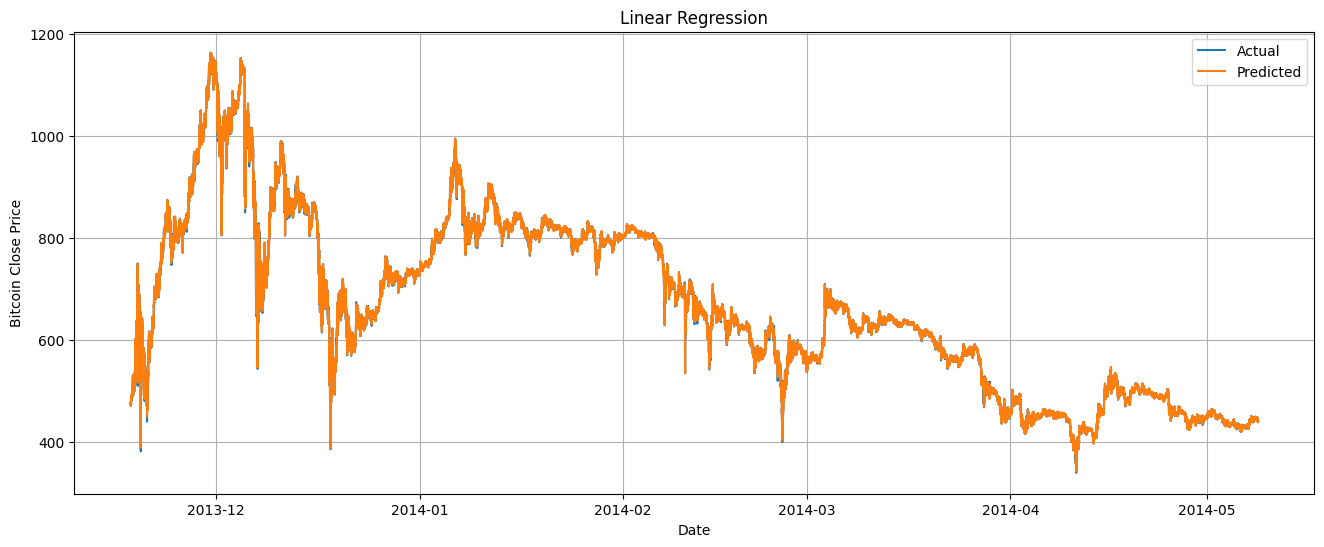

In [51]:
plt.figure(figsize=(16,6))
plt.plot(
lr_pd["Date"],
lr_pd["label"],
label="Actual"
)
plt.plot(
lr_pd["Date"],
lr_pd["prediction"],
label="Predicted"
)
plt.title("Linear Regression")
plt.xlabel("Date")
plt.ylabel("Bitcoin Close Price")
plt.legend()
plt.grid(True)
plt.show()

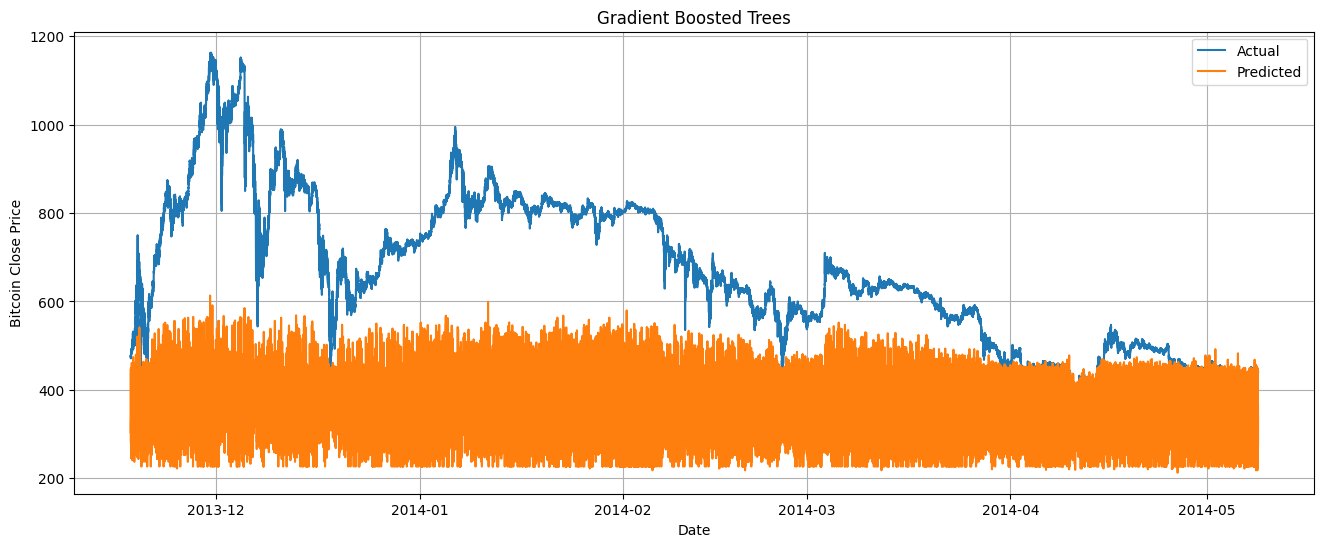

In [52]:
plt.figure(figsize=(16,6))
plt.plot(
gbt_pd["Date"],
gbt_pd["label"],
label="Actual"
)
plt.plot(
gbt_pd["Date"],
gbt_pd["prediction"],
label="Predicted"
)
plt.title("Gradient Boosted Trees")
plt.xlabel("Date")
plt.ylabel("Bitcoin Close Price")
plt.legend()
plt.grid(True)
plt.show()

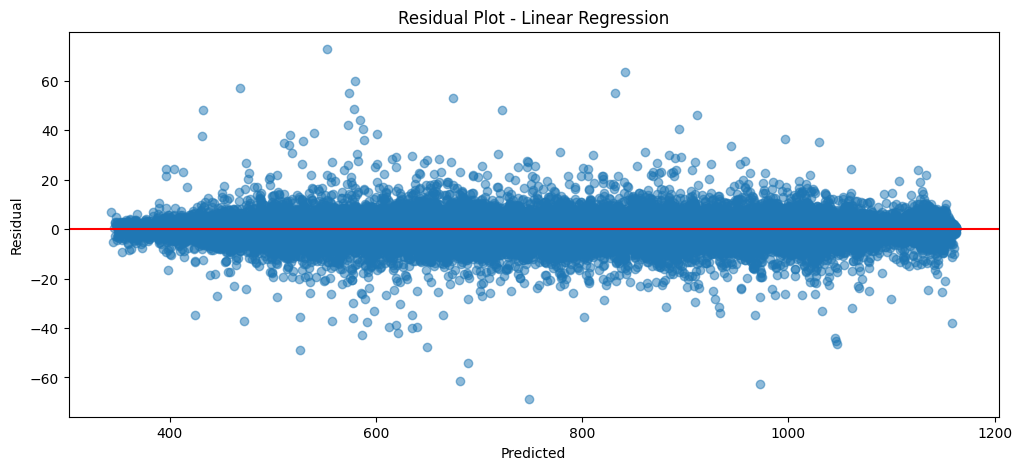

In [53]:
lr_pd["Residual"] = (
lr_pd["label"] -
lr_pd["prediction"]
)
plt.figure(figsize=(12,5))
plt.scatter(
lr_pd["prediction"],
lr_pd["Residual"],
alpha=0.5
)
plt.axhline(
0,
color="red"
)
plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

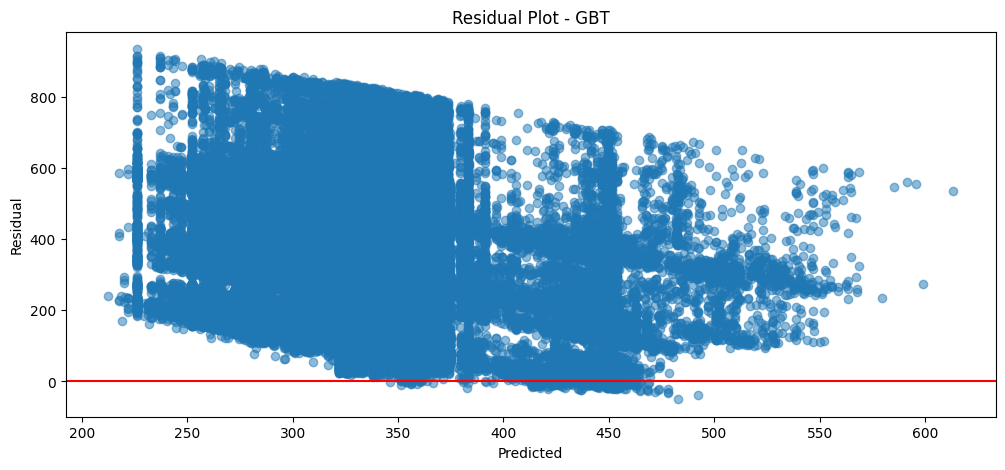

In [54]:
gbt_pd["Residual"] = (
gbt_pd["label"] -
gbt_pd["prediction"]
)
plt.figure(figsize=(12,5))
plt.scatter(
gbt_pd["prediction"],
gbt_pd["Residual"],
alpha=0.5
)
plt.axhline(
0,
color="red"
)
plt.title("Residual Plot - GBT")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

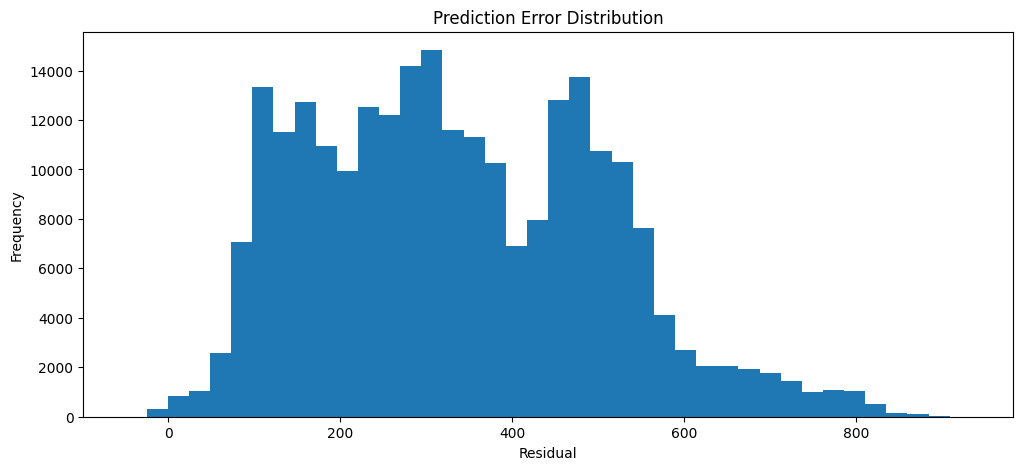

In [55]:
plt.figure(figsize=(12,5))
plt.hist(
gbt_pd["Residual"],
bins=40
)
plt.title("Prediction Error Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [56]:
importance = pd.DataFrame({
"Feature": feature_columns,
"Importance": gbt_model.featureImportances.toArray()
})
importance = importance.sort_values(
by="Importance",
ascending=False
)
importance

,Feature,Importance
1,High,0.669265
4,Lag_1,0.200751
2,Low,0.053977
13,Return,0.021094
12,Price_Change,0.018879
11,Rolling_Range,0.014378
3,Volume,0.007061
8,Rolling_STD,0.005552
10,Rolling_Min,0.004032
6,Lag_3,0.002140


<BarContainer object of 14 artists>

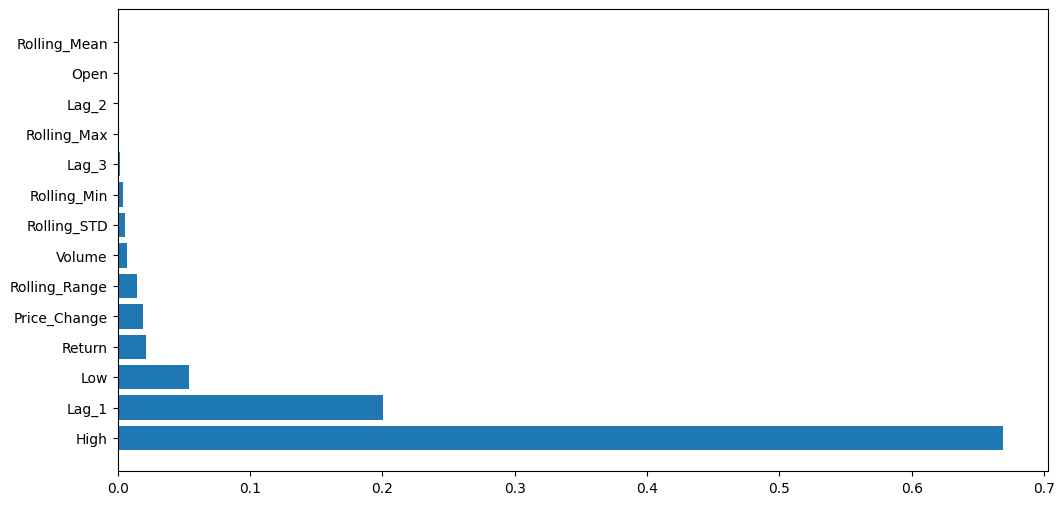

In [57]:
plt.figure(figsize=(12,6))
plt.barh(
importance["Feature"],
importance["Importance"]
)